# PR #23 — OpenKBP-Opt sample data + CT visualization

This notebook demos the functionality added in
[PR #23](https://github.com/EBHolm/openbragg/pull/23): a small, **committed**
openkbp-opt sample (`sample_data/openkbp_opt/`) plus fetch/curation tooling,
loaded and visualized through the real OpenBragg API.

It loads one curated patient from `sample_data/openkbp_opt/` (see that folder's
`README.md`) and visualizes its CT — orthogonal mid-planes, a slice montage, and
a structure overlay.

**Honest limits.** openkbp-opt is *photon* head-and-neck IMRT data on a downsampled
**128×128×128** grid, with the CT stored as offset/clipped 12-bit Hounsfield units
(0–4095, i.e. roughly true-HU + 1024). This exercises the loading + visualization
plumbing on real anatomy; it is **not** proton physics validation.

To run against the full dataset instead of the committed sample, set the
`OPENBRAGG_SAMPLE_DIR` environment variable to an `open-kbp-opt-data` root — its
`reference-plans/` patients load identically.

In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from openbragg.io.openkbp_opt import find_patient_dirs, load_case, resolve_plan_paths

# Sample location: OPENBRAGG_SAMPLE_DIR if set, else the committed sample_data/openkbp_opt
# (resolved from the repo root so the notebook runs from any working directory).
env_dir = os.environ.get("OPENBRAGG_SAMPLE_DIR", "").strip()
if env_dir:
    sample_dir = Path(env_dir).expanduser()
else:
    root = Path.cwd().resolve()
    while root != root.parent and not (root / "pyproject.toml").exists():
        root = root.parent
    sample_dir = root / "sample_data" / "openkbp_opt"

patients = find_patient_dirs(sample_dir)
if not patients:
    raise FileNotFoundError(
        f"No patients under {sample_dir}. Download + curate first:\n"
        "  uv run python scripts/fetch_openkbp.py --zip <base.zip> --zip <optional.zip>\n"
        "  uv run python scripts/make_openkbp_sample.py"
    )
patient_dir = patients[0]
print(f"sample dir: {sample_dir}")
print(f"patient:    {patient_dir.name}  ({len(patients)} available: {[p.name for p in patients]})")

sample dir: /Users/ebh/Documents/study/medical_physics/openbragg/sample_data/openkbp_opt
patient:    pt_278  (3 available: ['pt_278', 'pt_318', 'pt_329'])


In [2]:
# Load the case through the real package API (CT + structures + plan weights + dose).
fluence, dose = resolve_plan_paths(sample_dir, patient_dir.name)
case = load_case(patient_dir, fluence, dose if dose.is_file() else None)

ct = case.image.array
spacing = case.image.spacing_mm  # (dx, dy, dz) in mm
print(f"CT shape:      {ct.shape}")
print(f"voxel spacing: {spacing[0]:.3g} x {spacing[1]:.3g} x {spacing[2]:.3g} mm")
print(f"value range:   [{ct.min():.0f}, {ct.max():.0f}]  (offset 12-bit HU)")
print(f"structures:    {', '.join(case.structures.masks) or 'none'}")

# Robust display window from the volume's percentiles.
vmin, vmax = np.percentile(ct, [1.0, 99.5])

CT shape:      (128, 128, 128)
voxel spacing: 3.91 x 3.91 x 2.5 mm
value range:   [0, 2652]  (offset 12-bit HU)
structures:    Brainstem, SpinalCord, RightParotid, LeftParotid, PTV56, PTV63, PTV70


## Three orthogonal mid-planes

Each panel fixes one grid axis at its midpoint; the aspect ratio uses the true voxel
spacing so features are not stretched. Axes are labeled by grid index rather than by
anatomical orientation (openkbp does not ship an orientation we assert here).

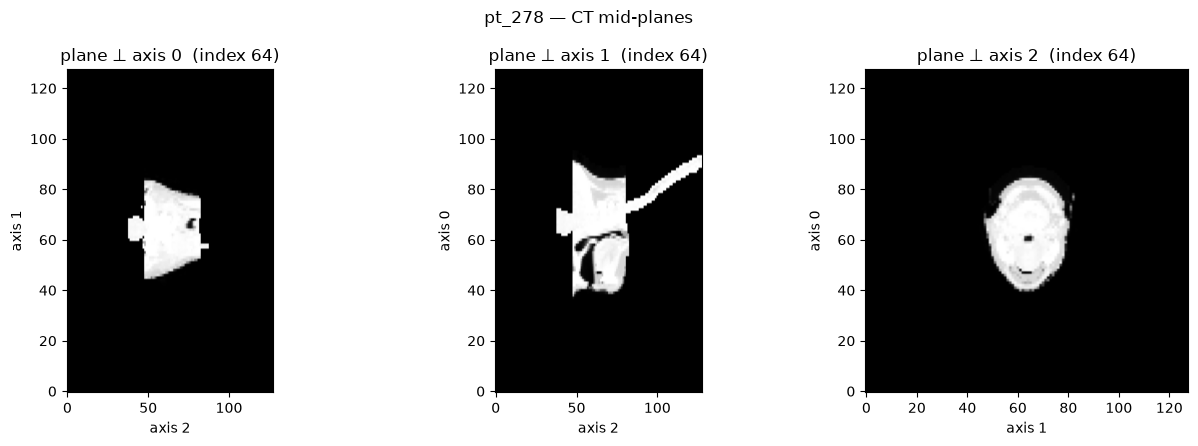

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
for axis, ax in enumerate(axes):
    idx = ct.shape[axis] // 2
    img = np.take(ct, idx, axis=axis)
    rem = [a for a in range(3) if a != axis]  # (row axis, col axis)
    aspect = spacing[rem[0]] / spacing[rem[1]]
    ax.imshow(img, cmap="gray", vmin=vmin, vmax=vmax, aspect=aspect, origin="lower")
    ax.set_title(f"plane ⊥ axis {axis}  (index {idx})")
    ax.set_xlabel(f"axis {rem[1]}")
    ax.set_ylabel(f"axis {rem[0]}")
fig.suptitle(f"{patient_dir.name} — CT mid-planes")
fig.tight_layout()
plt.show()

## Slice montage

Evenly spaced slices through the axis with the smallest voxel spacing (openkbp's
through-plane / superior–inferior direction), across the range that actually contains
anatomy.

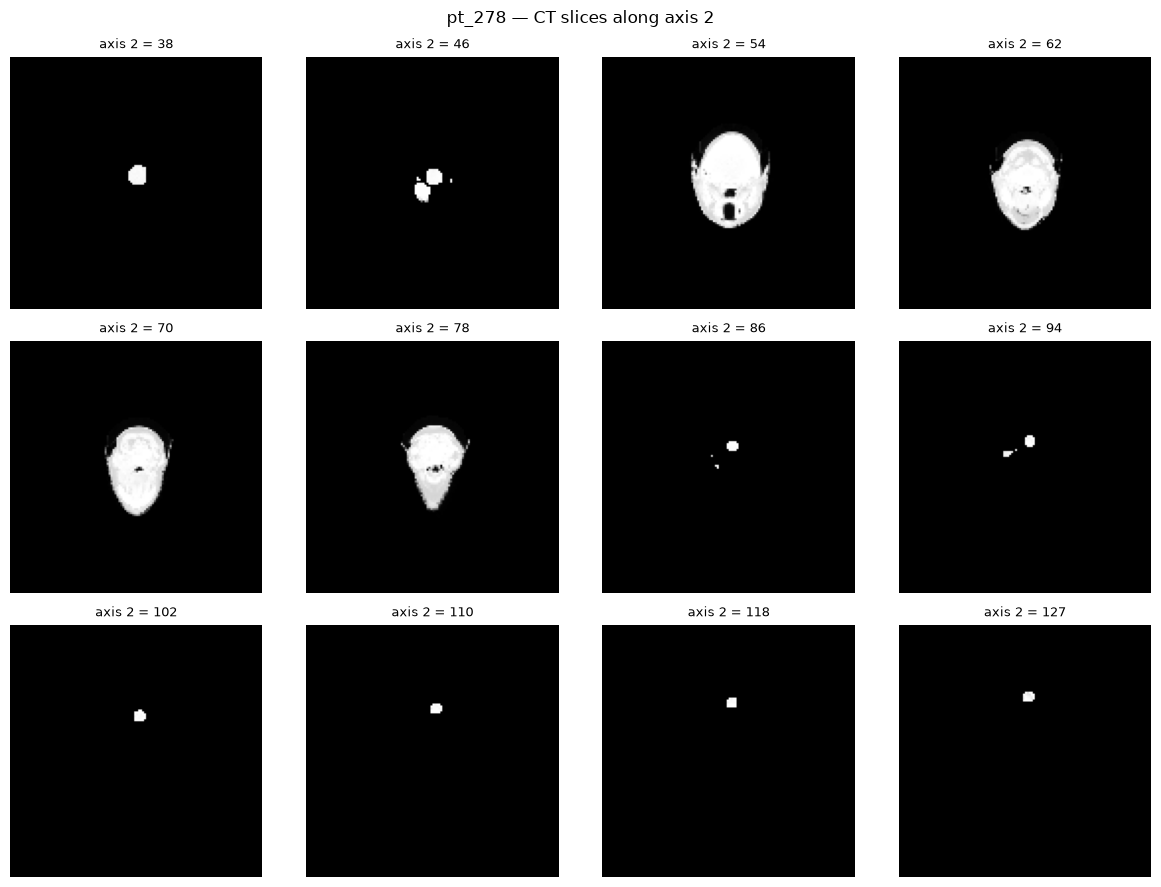

In [4]:
slice_axis = int(np.argmin(spacing))
# Restrict to slices that contain non-background voxels.
nonempty = [i for i in range(ct.shape[slice_axis]) if np.take(ct, i, axis=slice_axis).max() > vmin]
lo, hi = (nonempty[0], nonempty[-1]) if nonempty else (0, ct.shape[slice_axis] - 1)
idxs = np.linspace(lo, hi, 12, dtype=int)
rem = [a for a in range(3) if a != slice_axis]
aspect = spacing[rem[0]] / spacing[rem[1]]

fig, axes = plt.subplots(3, 4, figsize=(12, 9))
for idx, ax in zip(idxs, axes.ravel()):
    ax.imshow(np.take(ct, idx, axis=slice_axis), cmap="gray", vmin=vmin, vmax=vmax, aspect=aspect, origin="lower")
    ax.set_title(f"axis {slice_axis} = {idx}", fontsize=9)
    ax.axis("off")
fig.suptitle(f"{patient_dir.name} — CT slices along axis {slice_axis}")
fig.tight_layout()
plt.show()

## Structure overlay

A target/OAR contour drawn over the CT slice containing the most of that structure's
voxels — a quick check that masks and CT share the same grid.

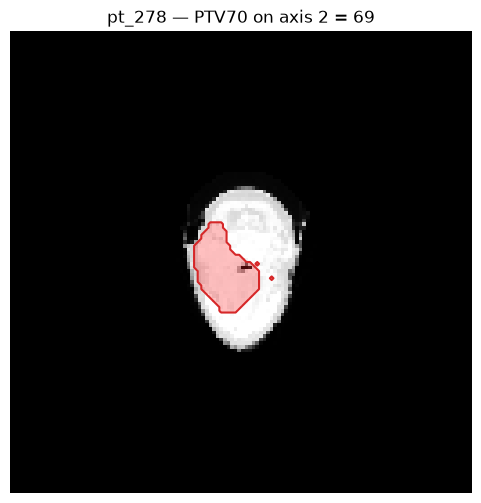

In [5]:
masks = case.structures.masks
if masks:
    name = "PTV70" if "PTV70" in masks else next(iter(masks))
    mask = masks[name]
    # Slice (along slice_axis) holding the most mask voxels.
    counts = [np.take(mask, i, axis=slice_axis).sum() for i in range(mask.shape[slice_axis])]
    idx = int(np.argmax(counts))
    ct2d = np.take(ct, idx, axis=slice_axis)
    mask2d = np.take(mask, idx, axis=slice_axis)

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(ct2d, cmap="gray", vmin=vmin, vmax=vmax, aspect=aspect, origin="lower")
    ax.contour(mask2d, levels=[0.5], colors="tab:red", linewidths=1.5)
    ax.imshow(np.ma.masked_where(~mask2d, mask2d), cmap="autumn", alpha=0.25, aspect=aspect, origin="lower")
    ax.set_title(f"{patient_dir.name} — {name} on axis {slice_axis} = {idx}")
    ax.axis("off")
    plt.show()
else:
    print("No structure masks in this case.")

---
The same `load_case(...)` API loads a full-dataset patient: point `OPENBRAGG_SAMPLE_DIR`
at a downloaded `open-kbp-opt-data` root, or regenerate the committed sample with
`scripts/fetch_openkbp.py` + `scripts/make_openkbp_sample.py`.